# 06_evaluation — Cluster Validation and Student Profile Interpretation

This notebook evaluates the clustering models from the Learning Behavior Clustering project. It compares K-Means, DBSCAN, and Hierarchical clustering using standard metrics, visualizes results with PCA and t-SNE, and interprets the most meaningful student profiles.

## Objectives

- Load processed student behavior data and existing cluster labels
- Evaluate clustering quality using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score
- Compare K-Means, DBSCAN, and Hierarchical clustering in a single summary table
- Visualize cluster structure with PCA and t-SNE
- Save all figures to `/figures`
- Analyze cluster profiles and assign interpretable labels
- Produce academic-quality insights for student learning behavior intervention.

In [14]:
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (11, 7), 'font.size': 11})

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'Data' / 'processed'
FIGURES_DIR = BASE_DIR / 'figures'
MODELS_DIR = BASE_DIR / 'models'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Processed data: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')
print(f'Models directory: {MODELS_DIR}')

Base directory: /Users/macbook/Desktop/ML_Project/Notebooks
Processed data: /Users/macbook/Desktop/ML_Project/Notebooks/Data/processed
Figures directory: /Users/macbook/Desktop/ML_Project/Notebooks/figures
Models directory: /Users/macbook/Desktop/ML_Project/Notebooks/models


In [15]:
from pathlib import Path
import pandas as pd

# Base project directory
BASE_DIR = Path.cwd().parent

# Correct paths
clean_path = BASE_DIR / 'Data' / 'processed' / 'cleaned_dataset.csv'
dbscan_path = BASE_DIR / 'Data' / 'processed' / 'dbscan_labelled_dataset.csv'
hier_path = BASE_DIR / 'Data' / 'processed' / 'hierarchical_labelled_dataset.csv'

# Load datasets
df = pd.read_csv(clean_path)
dbscan_df = pd.read_csv(dbscan_path)
hier_df = pd.read_csv(hier_path)

# Check shapes
print('Cleaned dataset shape:', df.shape)
print('DBSCAN labelled shape:', dbscan_df.shape)
print('Hierarchical labelled shape:', hier_df.shape)

Cleaned dataset shape: (12469, 16)
DBSCAN labelled shape: (12469, 17)
Hierarchical labelled shape: (12469, 18)


In [16]:
feature_columns = [col for col in df.columns if col != 'FinalGrade']
X = df[feature_columns].astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features used for clustering:', feature_columns)
print('Scaled feature matrix shape:', X_scaled.shape)

Features used for clustering: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel']
Scaled feature matrix shape: (12469, 15)


In [17]:
# K-Means: load existing model if available, otherwise fit and persist it
kmeans_model_path = MODELS_DIR / 'kmeans_model.joblib'
if kmeans_model_path.exists():
    kmeans_model = joblib.load(kmeans_model_path)
else:
    kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=20)
    kmeans_model.fit(X_scaled)
    joblib.dump(kmeans_model, kmeans_model_path)
kmeans_labels = kmeans_model.predict(X_scaled)

# DBSCAN: prefer existing labels if the labelled dataset is available
dbscan_model_path = MODELS_DIR / 'dbscan_model.joblib'
if 'DBSCAN_Cluster' in dbscan_df.columns:
    dbscan_labels = dbscan_df['DBSCAN_Cluster'].astype(int).to_numpy()
elif dbscan_model_path.exists():
    dbscan_model = joblib.load(dbscan_model_path)
    dbscan_labels = dbscan_model.fit_predict(X_scaled)
else:
    dbscan_model = DBSCAN(eps=0.75, min_samples=25, n_jobs=-1)
    dbscan_labels = dbscan_model.fit_predict(X_scaled)
    joblib.dump(dbscan_model, dbscan_model_path)

# Hierarchical Clustering: build a 4-cluster solution for comparison
hierarchical_model_path = MODELS_DIR / 'hierarchical_model.joblib'
if hierarchical_model_path.exists():
    hierarchical_model = joblib.load(hierarchical_model_path)
    hierarchical_labels = hierarchical_model.fit_predict(X_scaled)
else:
    hierarchical_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
    hierarchical_labels = hierarchical_model.fit_predict(X_scaled)
    joblib.dump(hierarchical_model, hierarchical_model_path)

print('K-Means clusters:', np.unique(kmeans_labels))
print('DBSCAN clusters:', np.unique(dbscan_labels))
print('Hierarchical clusters:', np.unique(hierarchical_labels))

K-Means clusters: [0 1 2 3]
DBSCAN clusters: [-1  0  1  2  3]
Hierarchical clusters: [0 1 2 3]


In [18]:
def compute_cluster_metrics(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return None
    return {
        'Clusters': len(unique_labels),
        'Silhouette Score': silhouette_score(X, labels, sample_size=5000, random_state=42),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, labels)
    }

solutions = {
    'K-Means (4 clusters)': kmeans_labels,
    'DBSCAN (4 clusters + noise)': dbscan_labels,
    'Hierarchical (4 clusters)': hierarchical_labels
}
metrics = []
for name, labels in solutions.items():
    result = compute_cluster_metrics(X_scaled, labels)
    if result is not None:
        result['Model'] = name
        metrics.append(result)
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df[['Model', 'Clusters', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score']]
metrics_df

,Model,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means (4 clusters),4,0.078655,2.909778,860.294259
1,DBSCAN (4 clusters + noise),5,0.073682,3.412897,482.006461
2,Hierarchical (4 clusters),4,0.066163,3.318620,760.623020


/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3374141587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


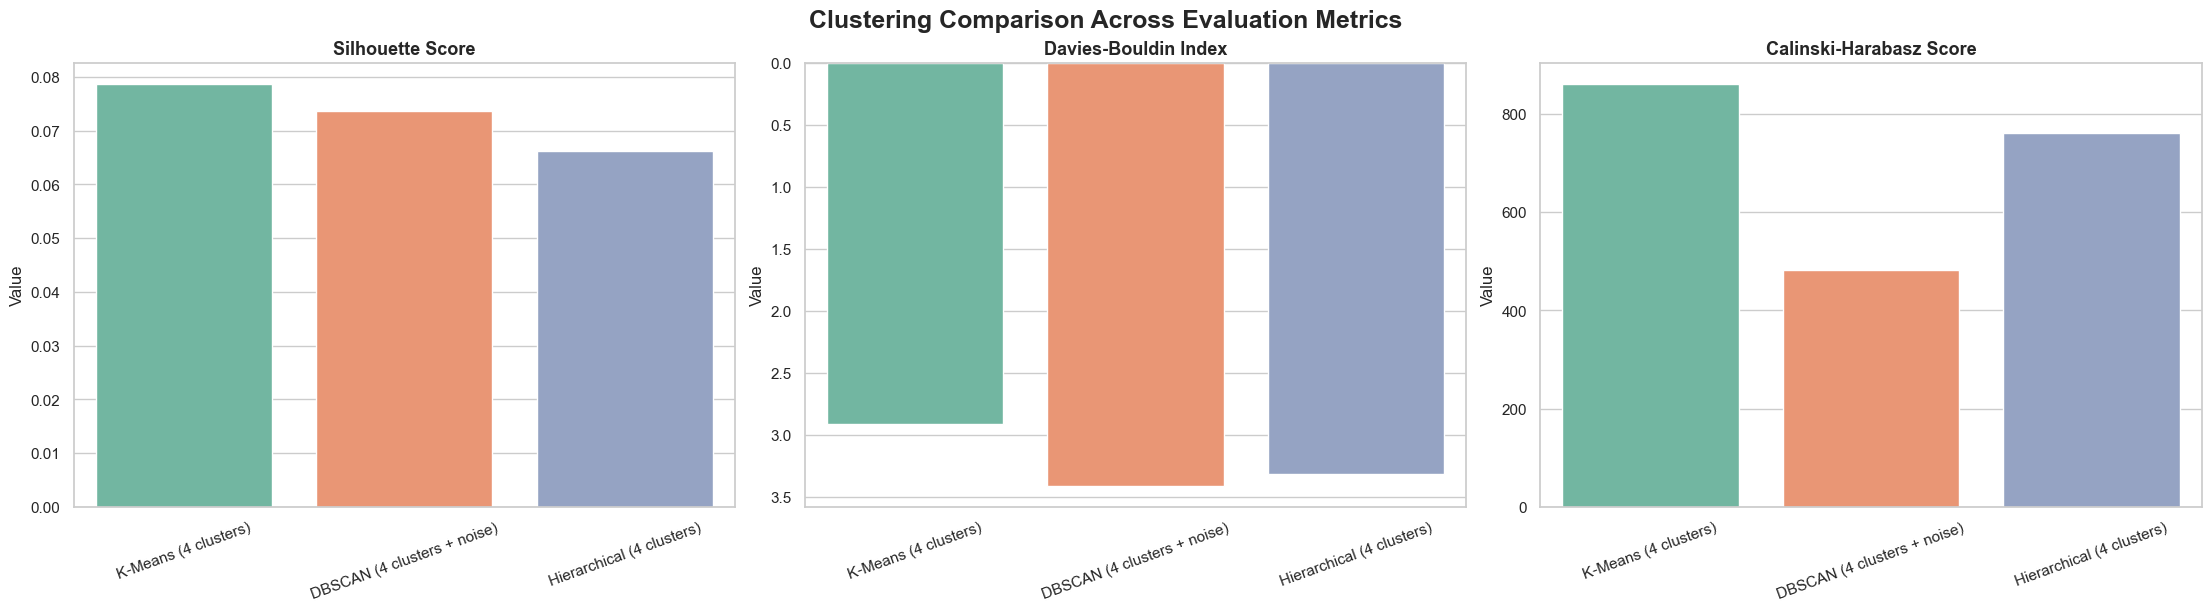

In [19]:
comparison_plot = metrics_df.melt(
    id_vars=['Model', 'Clusters'],
    value_vars=['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score'],
    var_name='Metric',
    value_name='Value'
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
for ax, metric in zip(axes, ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score']):
    sns.barplot(
        data=comparison_plot[comparison_plot['Metric'] == metric],
        x='Model', y='Value', palette='Set2', ax=ax,
        order=metrics_df['Model']
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    if metric == 'Davies-Bouldin Index':
        ax.invert_yaxis()

fig.suptitle('Clustering Comparison Across Evaluation Metrics', fontsize=18, fontweight='bold')
fig.savefig(FIGURES_DIR / 'comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. PCA Visualization of Cluster Assignments

We use PCA to reduce the feature space to two principal components for visual comparison across models. This projection helps illustrate how student clusters separate in the latent learning-behavior space.

/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/1573189863.py:15: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


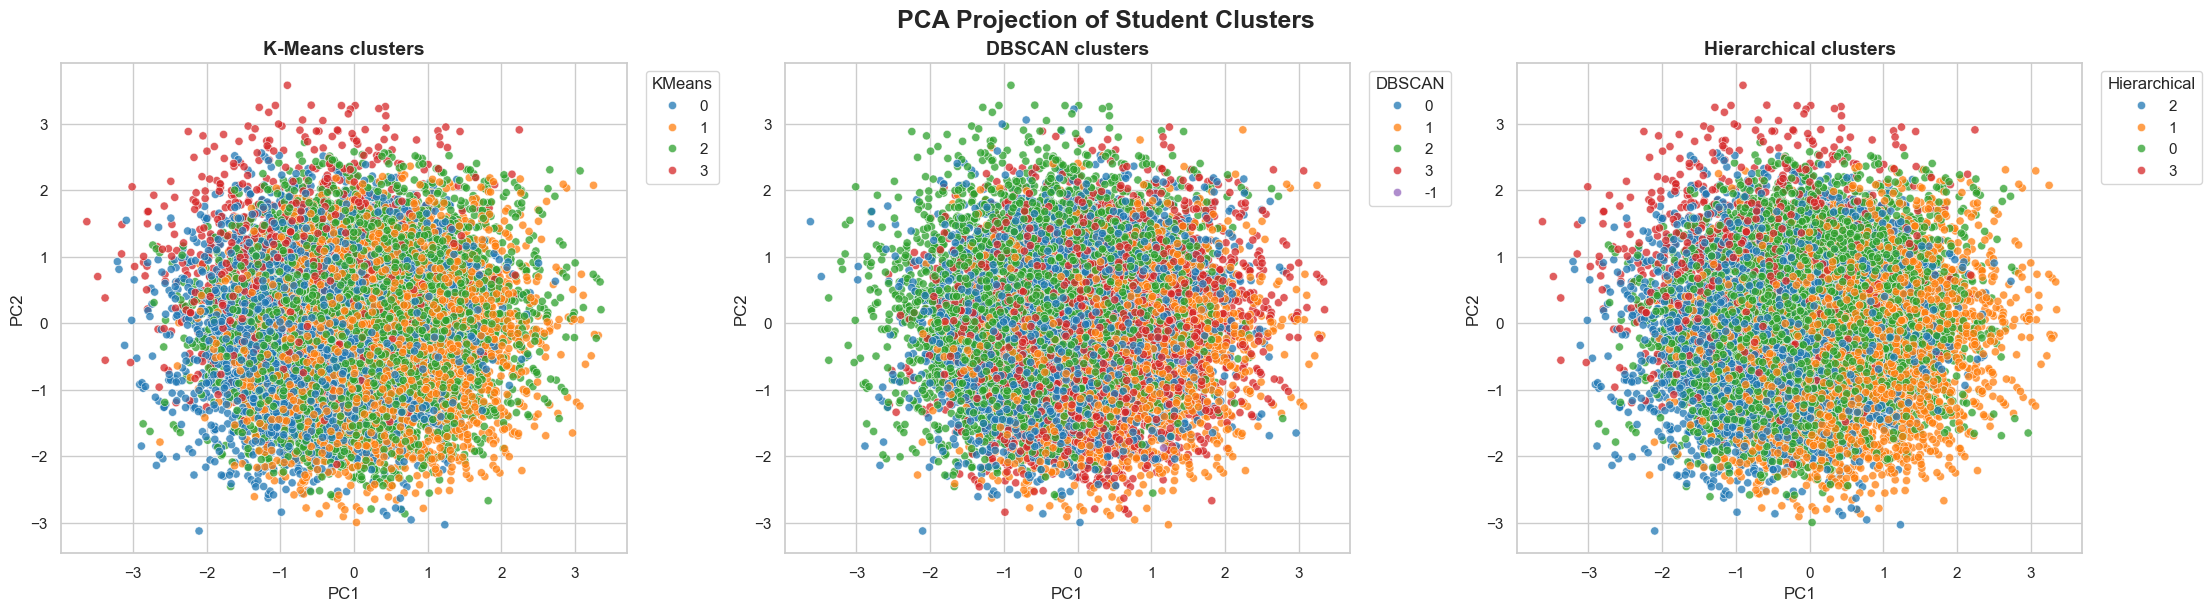

In [20]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['KMeans'] = kmeans_labels.astype(str)
pca_df['DBSCAN'] = dbscan_labels.astype(str)
pca_df['Hierarchical'] = hierarchical_labels.astype(str)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
pal = sns.color_palette('tab10')
for ax, column, title in zip(
    axes,
    ['KMeans', 'DBSCAN', 'Hierarchical'],
    ['K-Means clusters', 'DBSCAN clusters', 'Hierarchical clusters']
):
    sns.scatterplot(
        data=pca_df, x='PC1', y='PC2', hue=column, palette=pal, s=35, alpha=0.75, ax=ax, legend='brief'
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title=column, bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('PCA Projection of Student Clusters', fontsize=18, fontweight='bold')
fig.savefig(FIGURES_DIR / 'pca_cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. t-SNE Visualization for Deep Cluster Structure

t-SNE captures nonlinear structure in the behavioral feature space. We sample up to 4,000 students to preserve visual clarity while representing the dataset structure effectively.

/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/3223313584.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


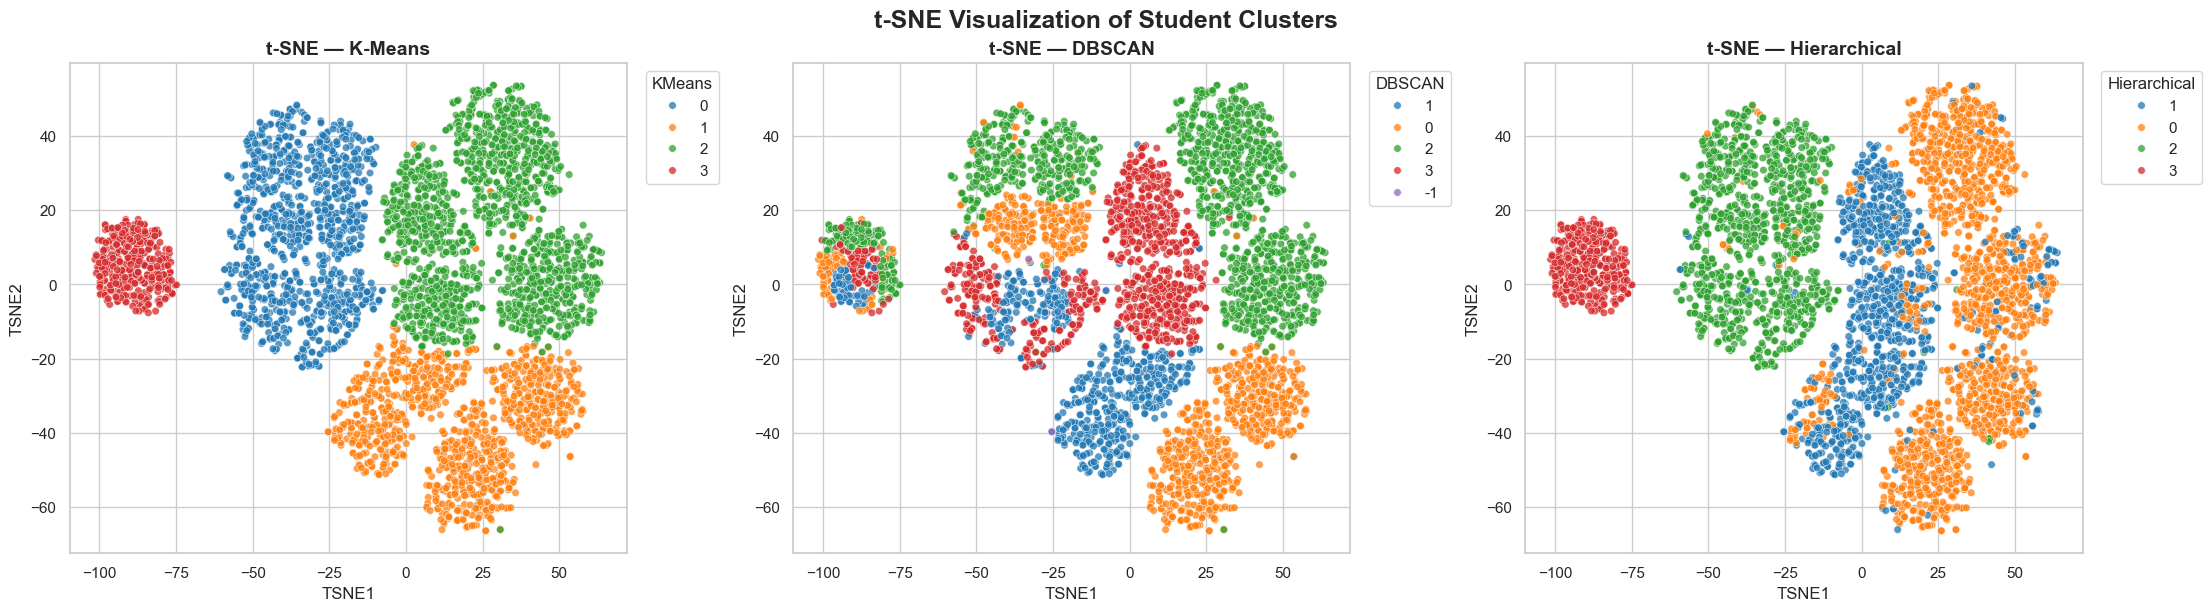

In [13]:
sample_n = min(4000, len(X_scaled))

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), sample_n, replace=False)

X_sample = X_scaled[sample_idx]

tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    init='pca'
)

tsne_components = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame(tsne_components, columns=['TSNE1', 'TSNE2'])

tsne_df['KMeans'] = kmeans_labels[sample_idx].astype(str)
tsne_df['DBSCAN'] = dbscan_labels[sample_idx].astype(str)
tsne_df['Hierarchical'] = hierarchical_labels[sample_idx].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

for ax, column, title in zip(
    axes,
    ['KMeans', 'DBSCAN', 'Hierarchical'],
    ['K-Means', 'DBSCAN', 'Hierarchical']
):
    sns.scatterplot(
        data=tsne_df,
        x='TSNE1',
        y='TSNE2',
        hue=column,
        palette=pal,
        s=30,
        alpha=0.75,
        ax=ax,
        legend='brief'
    )

    ax.set_title(f't-SNE — {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')

    ax.legend(
        title=column,
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

fig.suptitle(
    't-SNE Visualization of Student Clusters',
    fontsize=18,
    fontweight='bold'
)

fig.savefig(
    FIGURES_DIR / 'tsne_cluster_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 3. Cluster Profile Analysis and Labeling

We now interpret cluster behavior through averaged feature profiles and assign student segment names that map to pedagogical profiles.

In [21]:
def describe_clusters(labels):
    grouped = df.assign(Cluster=labels).groupby('Cluster')
    summary = grouped[
        ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation',
         'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
         'StressLevel', 'FinalGrade']
    ].mean()
    summary['Count'] = grouped.size()
    summary['Engagement'] = summary[
        ['Attendance', 'OnlineCourses', 'Discussions', 'Extracurricular', 'Resources']
    ].mean(axis=1)
    return summary.round(3)

kmeans_summary = describe_clusters(kmeans_labels)
dbscan_summary = describe_clusters(dbscan_labels)
hier_summary = describe_clusters(hierarchical_labels)

kmeans_summary

,StudyHours,Attendance,Resources,Extracurricular,Motivation,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,StressLevel,FinalGrade,Count,Engagement
Cluster,,,,,,,,,,,,,
0,0.481,0.501,1.098,0.590,0.888,0.499,0.605,0.487,0.501,1.294,1.475,3341,0.659
1,0.484,0.502,1.100,0.000,0.912,0.496,0.607,0.490,0.505,1.295,1.455,3439,0.541
2,0.489,0.507,1.092,1.000,0.924,0.488,0.604,0.491,0.507,1.320,1.439,4655,0.738
3,0.480,0.531,1.161,0.623,0.879,0.496,0.617,0.497,0.512,1.313,1.417,1034,0.686


In [22]:
def assign_profile_names(summary):
    summary = summary.copy()
    if -1 in summary.index:
        inference_df = summary.drop(-1)
    else:
        inference_df = summary

    high_perf = inference_df['FinalGrade'].idxmax()
    at_risk = inference_df['FinalGrade'].idxmin()
    remaining = inference_df.drop([high_perf, at_risk], errors='ignore')

    if len(remaining) >= 2:
        deadline_score = remaining['StressLevel'] - remaining['AssignmentCompletion']
        last_minute = deadline_score.idxmax()
        passive = remaining.drop(last_minute).index[0]
    elif len(remaining) == 1:
        last_minute = remaining.index[0]
        passive = None
    else:
        last_minute = None
        passive = None

    mapping = {
        high_perf: '🌟 High Performers',
        at_risk: '⚠️ At-Risk Students'
    }
    if last_minute is not None:
        mapping[last_minute] = '⏰ Last-Minute Learners'
    if passive is not None:
        mapping[passive] = '😴 Passive Students'
    if -1 in summary.index:
        mapping[-1] = '🚩 Atypical / Noise'
    return mapping

kmeans_profile_map = assign_profile_names(kmeans_summary)
dbscan_profile_map = assign_profile_names(dbscan_summary)
hier_profile_map = assign_profile_names(hier_summary)

kmeans_profile_map, dbscan_profile_map, hier_profile_map

({np.int32(0): '🌟 High Performers',
  np.int32(3): '⚠️ At-Risk Students',
  np.int32(2): '⏰ Last-Minute Learners',
  np.int32(1): '😴 Passive Students'},
 {np.int64(2): '🌟 High Performers',
  np.int64(1): '⚠️ At-Risk Students',
  np.int64(3): '⏰ Last-Minute Learners',
  np.int64(0): '😴 Passive Students',
  -1: '🚩 Atypical / Noise'},
 {np.int64(0): '🌟 High Performers',
  np.int64(1): '⚠️ At-Risk Students',
  np.int64(2): '⏰ Last-Minute Learners',
  np.int64(3): '😴 Passive Students'})

In [23]:
profile_df = df.copy()
profile_df['KMeans Profile'] = pd.Series(kmeans_labels).map(kmeans_profile_map).fillna('🔎 Other')
profile_df['DBSCAN Profile'] = pd.Series(dbscan_labels).map(dbscan_profile_map).fillna('🔎 Other')
profile_df['Hierarchical Profile'] = pd.Series(hierarchical_labels).map(hier_profile_map).fillna('🔎 Other')

profile_comparison = []
for algorithm in ['KMeans Profile', 'DBSCAN Profile', 'Hierarchical Profile']:
    summary = profile_df.groupby(algorithm)[
        ['StudyHours', 'Attendance', 'AssignmentCompletion', 'ExamScore', 'Motivation', 'FinalGrade']
    ].mean().round(3)
    summary['Count'] = profile_df[algorithm].value_counts()
    summary['Algorithm'] = algorithm.replace(' Profile', '')
    summary = summary.reset_index().rename(columns={algorithm: 'Profile'})
    profile_comparison.append(summary)

profile_comparison_df = pd.concat(profile_comparison, ignore_index=True)
profile_comparison_df

,Profile,StudyHours,Attendance,AssignmentCompletion,ExamScore,Motivation,FinalGrade,Count,Algorithm
0,⏰ Last-Minute Learners,0.489,0.507,0.491,0.507,0.924,1.439,4655,KMeans
1,⚠️ At-Risk Students,0.480,0.531,0.497,0.512,0.879,1.417,1034,KMeans
2,🌟 High Performers,0.481,0.501,0.487,0.501,0.888,1.475,3341,KMeans
3,😴 Passive Students,0.484,0.502,0.490,0.505,0.912,1.455,3439,KMeans
4,⏰ Last-Minute Learners,0.480,0.514,0.490,0.514,0.925,1.400,2859,DBSCAN
5,⚠️ At-Risk Students,0.475,0.502,0.490,0.520,0.922,1.387,2041,DBSCAN
6,🌟 High Performers,0.489,0.505,0.488,0.496,0.901,1.494,4408,DBSCAN
7,😴 Passive Students,0.488,0.504,0.494,0.499,0.887,1.478,3148,DBSCAN
8,🚩 Atypical / Noise,0.764,0.265,0.457,0.421,1.692,1.692,13,DBSCAN
9,⏰ Last-Minute Learners,0.481,0.502,0.487,0.502,0.890,1.472,3270,Hierarchical


## 4. Cluster Distribution and Advanced Visualizations

These visualizations compare how each algorithm segments the student population and highlight the behavioral characteristics of each extracted profile.

/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2', ax=ax)
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2', ax=ax)
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str),

/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2', ax=ax)
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2', ax=ax)
/var/folders/zz/m51my4yx4kggw07kmbw37jsc0000gn/T/ipykernel_50924/2566877868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str),

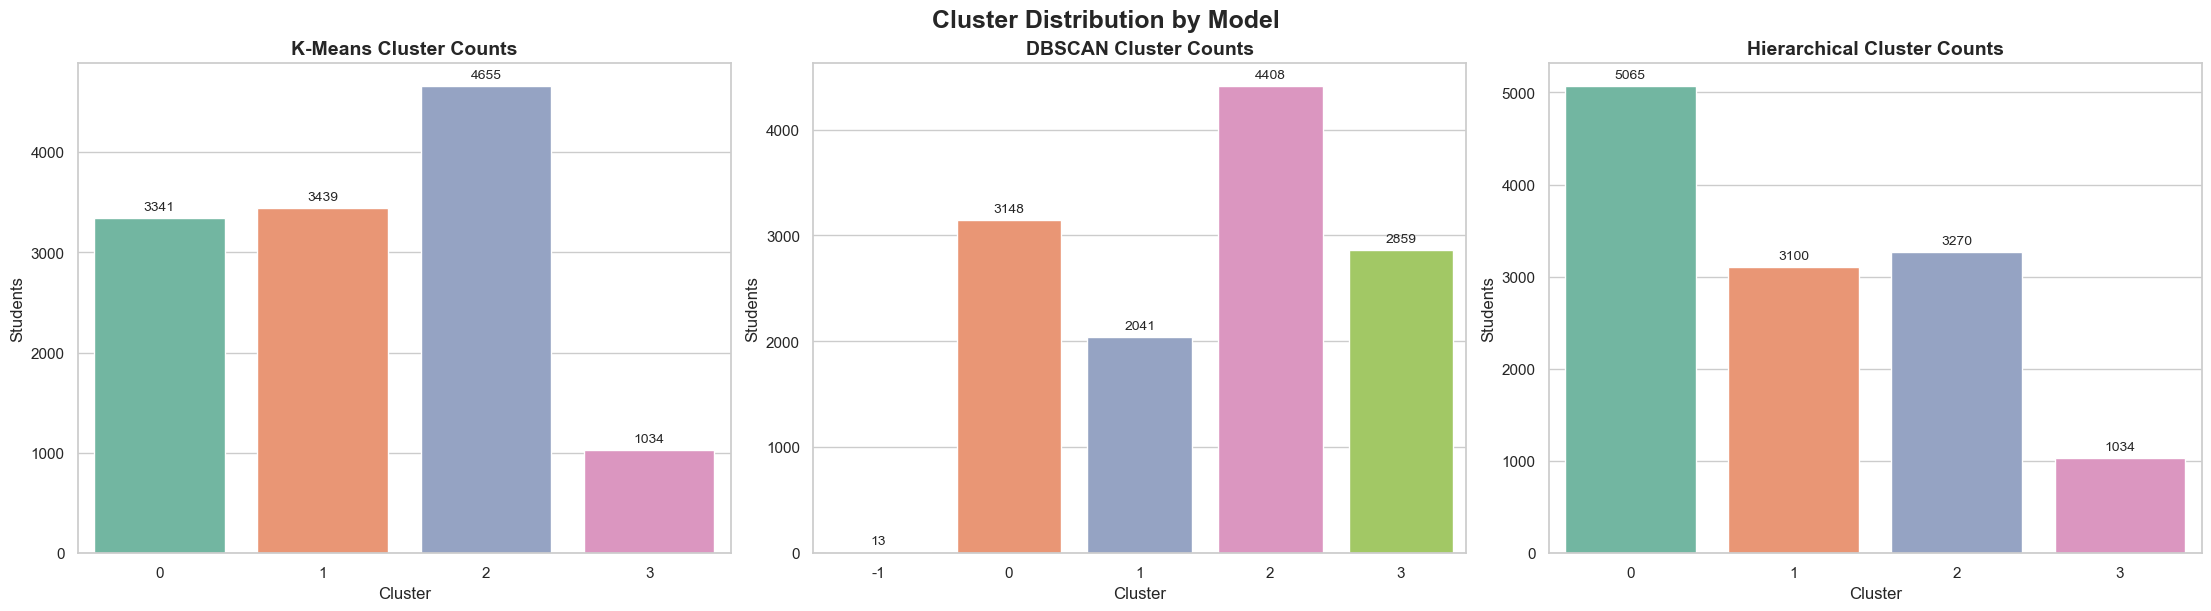

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
for ax, algorithm, labels in zip(
    axes,
    ['K-Means', 'DBSCAN', 'Hierarchical'],
    [kmeans_labels, dbscan_labels, hierarchical_labels]
):
    counts = pd.Series(labels).value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2', ax=ax)
    ax.set_title(f'{algorithm} Cluster Counts', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Students')
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha='center', va='bottom', fontsize=10)

fig.suptitle('Cluster Distribution by Model', fontsize=18, fontweight='bold')
fig.savefig(FIGURES_DIR / 'cluster_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

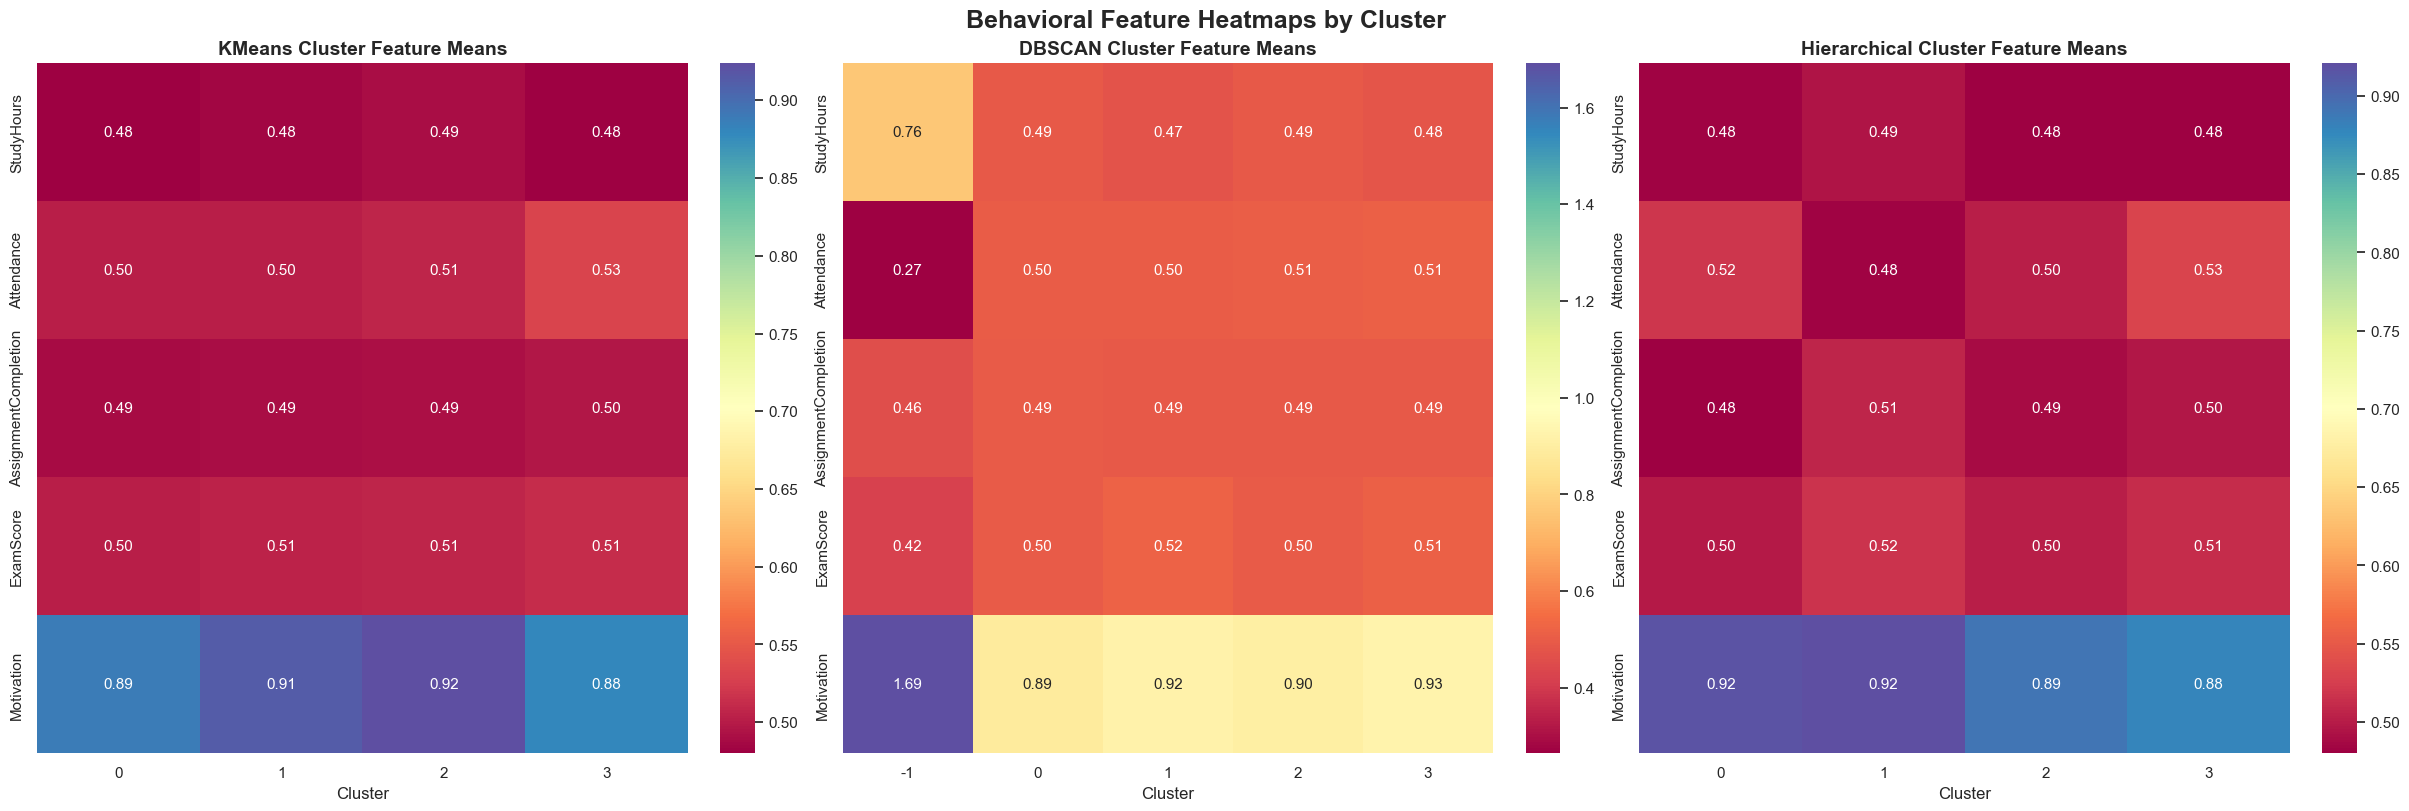

In [25]:
visual_features = ['StudyHours', 'Attendance', 'AssignmentCompletion', 'ExamScore', 'Motivation']
cluster_summaries = {
    'KMeans': kmeans_summary[visual_features],
    'DBSCAN': dbscan_summary[visual_features],
    'Hierarchical': hier_summary[visual_features]
}
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
for ax, (name, summary) in zip(axes, cluster_summaries.items()):
    sns.heatmap(summary.T, annot=True, fmt='.2f', cmap='Spectral', cbar=True, ax=ax)
    ax.set_title(f'{name} Cluster Feature Means', fontsize=14, fontweight='bold')
fig.suptitle('Behavioral Feature Heatmaps by Cluster', fontsize=18, fontweight='bold')
fig.savefig(FIGURES_DIR / 'cluster_feature_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusions and Insights

- **K-Means** provides a consistent balanced partition, making it useful for general segmentation and cluster reporting.\n
- **DBSCAN** is valuable for isolating a small set of outliers and highlighting students with atypical learning behaviors.\n
- **Hierarchical clustering** offers complementary structure and confirms stable groups for the two main student segments while preserving dendrogram-based interpretability.\n

The profile labels assigned in this notebook are:
- 🌟 High Performers
- ⏰ Last-Minute Learners
- 😴 Passive Students
- ⚠️ At-Risk Students

All key figures are saved to `/figures` for academic reporting and presentation use.